Match Face
0.6635426110839631


(np.float64(-0.5), np.float64(460.5), np.float64(370.5), np.float64(-0.5))

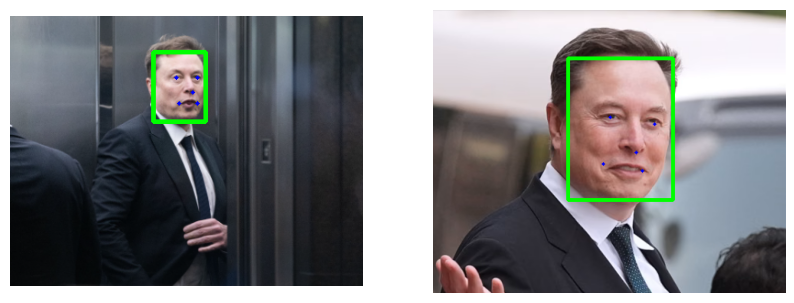

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# Load images
image1 = cv.imread("Images/Elon.png")
image2 = cv.imread("Images/Elon2.png")

height, width, _ = image1.shape


# Create face detector
face_detector = cv.FaceDetectorYN.create(
    "model/face/face_detection_yunet_2023mar.onnx",
    "",
    (320, 320),
    0.9,
    0.3,
    5000
)


def draw_faces(image, result):
    """Draw face box and landmarks."""

    if result[0]:
        faces = result[1]

        for face in faces:
            face = np.int32(face)

            x, y, w, h = face[:4]

            cv.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 3)

            cv.circle(image, (face[4], face[5]), 2, (255, 0, 0), -1)
            cv.circle(image, (face[6], face[7]), 2, (255, 0, 0), -1)
            cv.circle(image, (face[8], face[9]), 2, (255, 0, 0), -1)
            cv.circle(image, (face[10], face[11]), 2, (255, 0, 0), -1)
            cv.circle(image, (face[12], face[13]), 2, (255, 0, 0), -1)


def recognize_faces(recognizer, image1, image2, face1, face2):
    """Extract features and compare faces."""

    aligned_face1 = recognizer.alignCrop(image1, face1)
    aligned_face2 = recognizer.alignCrop(image2, face2)

    feature1 = recognizer.feature(aligned_face1)
    feature2 = recognizer.feature(aligned_face2)

    return recognizer.match(
        feature1,
        feature2,
        cv.FaceRecognizerSF_FR_NORM_L2
    )


# Detect face in first image
face_detector.setInputSize((width, height))

result1 = face_detector.detect(image1)

image1_copy = image1.copy()

if result1[0]:
    draw_faces(image1_copy, result1)


# Detect face in second image
height2, width2, _ = image2.shape

face_detector.setInputSize((width2, height2))

result2 = face_detector.detect(image2)

image2_copy = image2.copy()

if result2[0]:
    draw_faces(image2_copy, result2)


# Create face recognizer
face_recognizer = cv.FaceRecognizerSF.create(
    "model/face/face_recognition_sface_2021dec.onnx",
    ""
)

threshold = 1.128

score = recognize_faces(
    face_recognizer,
    image1,
    image2,
    result1[1][0],
    result2[1][0]
)

message = "Different Face"

if score <= threshold:
    message = "Match Face"

print(message)
print(score)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image1_copy[...,::-1])
ax[0].axis("off")
ax[1].imshow(image2_copy[...,::-1])
ax[1].axis("off")

Different Face
1.3512003253132603


(np.float64(-0.5), np.float64(411.5), np.float64(409.5), np.float64(-0.5))

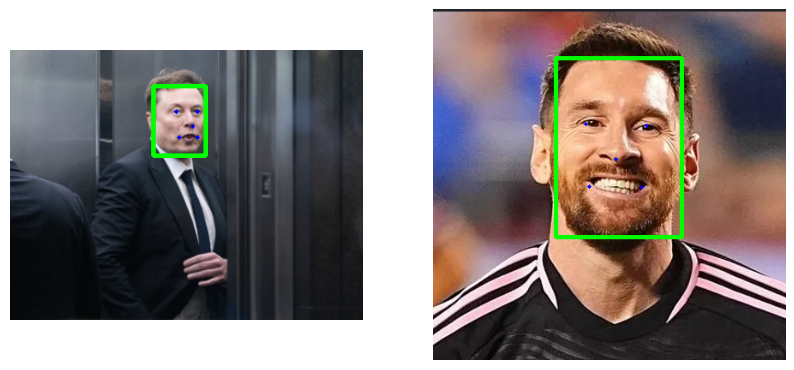

In [32]:
image2 = cv.imread("Images/Messi.png")


# Detect with another person
height2, width2, _ = image2.shape

face_detector.setInputSize((width2, height2))

result2 = face_detector.detect(image2)

image2_copy = image2.copy()

if result2[0]:
    draw_faces(image2_copy, result2)


# Create face recognizer
face_recognizer = cv.FaceRecognizerSF.create(
    "model/face/face_recognition_sface_2021dec.onnx",
    ""
)

threshold = 1.128

score = recognize_faces(
    face_recognizer,
    image1,
    image2,
    result1[1][0],
    result2[1][0]
)

message = "Different Face"

if score <= threshold:
    message = "Match Face"

print(message)
print(score)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image1_copy[...,::-1])
ax[0].axis("off")
ax[1].imshow(image2_copy[...,::-1])
ax[1].axis("off")